# 01 - Correccion de senales sismicas

Este notebook queda ordenado en el mismo orden de decision que se espera en un procesamiento academico reproducible:

1. Cargar y revisar el registro.
2. Probar correccion por linea base con coeficientes escritos por el usuario: constante, lineal y cuadratica.
3. Aplicar filtrado de ruido con todos los parametros definidos manualmente por el usuario.
4. Ejecutar la recomendacion automatica y revisar por que gano el candidato seleccionado.
5. Comparar el resultado manual, el recomendado y los canales USGS publicados.

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from signalprocessor.io import read_motion
from signalprocessor.metrics import (
    compute_ground_motion_parameters,
    compute_ground_motion_parameters_from_series,
    cumulative_arias,
    ground_motion_parameters_to_dict,
    integrate_motion,
)
from signalprocessor.processing import CorrectionConfig, correct_record
from signalprocessor.recommendation import recommend_correction_method
from signalprocessor.spectra import fourier_amplitude_spectrum, response_spectrum

## Datos de entrada

Se usa un componente SMC sin corregir y los productos USGS corregidos correspondientes: aceleracion (`_a`), velocidad (`_v`) y desplazamiento (`_d`). Los canales de velocidad y desplazamiento USGS se leen como series numericas publicadas para comparar metricas sin reintegrar la aceleracion.

In [2]:
component = 'CCSP.HNN..'
raw_path = ROOT / f'examples/data/benchmark/uncorrected_motion/{component}_u.smc'
ref_acc_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_a.smc'
ref_vel_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_v.smc'
ref_disp_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_d.smc'

raw = read_motion(raw_path)
reference_acc = read_motion(ref_acc_path, units='cm/s^2')
reference_vel = read_motion(ref_vel_path, units='cm/s^2')   # numericamente cm/s
reference_disp = read_motion(ref_disp_path, units='cm/s^2') # numericamente cm

pd.DataFrame([{
    'component': component,
    'npts': raw.npts,
    'dt_s': raw.dt,
    'duration_s': raw.duration,
    'units': raw.units,
    'pga_raw_cm_s2': np.max(np.abs(raw.as_units('cm/s^2').acceleration)),
}])

,component,npts,dt_s,duration_s,units,pga_raw_cm_s2
0,CCSP.HNN..,20200,0.01,201.99,cm/s^2,634.16


## Convencion usada para la linea base

Los coeficientes manuales se entregan en SI, en `m/s^2`, y se interpretan como un polinomio de aceleracion sobre una coordenada normalizada `tau` entre 0 y 1:

`b(tau) = c0 + c1*tau + c2*tau**2 + ...`

La correccion resta esa linea base: `a_corregida = a_original - b(tau)`. Si `remove_mean=True`, la remocion de media ocurre antes de aplicar estos coeficientes; en los ejemplos de coeficientes explicitos se usa `remove_mean=False` para que el usuario vea exactamente el efecto de los valores escritos.

In [3]:
def coefficients_to_text(coefficients):
    if coefficients is None:
        return ''
    arr = np.asarray(coefficients, dtype=float).ravel()
    if arr.size == 0:
        return ''
    return ', '.join(f'{value:.10g}' for value in arr)


def coefficients_to_text_cm_s2(coefficients):
    if coefficients is None:
        return ''
    arr = np.asarray(coefficients, dtype=float).ravel()
    if arr.size == 0:
        return ''
    return ', '.join(f'{100.0 * value:.10g}' for value in arr)


def baseline_curve_from_coefficients(coefficients, npts):
    if coefficients is None:
        return None
    arr = np.asarray(coefficients, dtype=float).ravel()
    if arr.size == 0:
        return None
    tau = np.linspace(0.0, 1.0, npts)
    design = np.vander(tau, N=arr.size, increasing=True)
    return design @ arr


def metrics_row(label, params):
    return ground_motion_parameters_to_dict(
        params,
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': label}

## 1. Correccion por linea base con coeficientes del usuario

Estos casos no filtran la senal ni estiman coeficientes. Solo muestran como el usuario puede escribir una correccion constante, lineal o cuadratica y revisar su efecto inicial en aceleracion, velocidad y desplazamiento.

In [4]:
USER_BASELINE_CASES = {
    'constante': (-0.050,),
    'lineal': (-0.050, 0.015),
    'cuadratico': (-0.050, 0.015, -0.004),
}

baseline_only_results = {}
for name, coeffs in USER_BASELINE_CASES.items():
    cfg = CorrectionConfig(
        remove_mean=False,
        baseline_order=-1,
        baseline_coefficients=coeffs,
        constrain_final_velocity=False,
        constrain_final_displacement=False,
        despike=False,
        taper_fraction=0.0,
        highpass_hz=None,
        lowpass_hz=None,
        post_filter_baseline_order=None,
    )
    baseline_only_results[name] = correct_record(raw, cfg)

baseline_examples_table = pd.DataFrame([
    {
        'caso': name,
        'orden': len(coeffs) - 1,
        'coeficientes_m_s2': coefficients_to_text(coeffs),
        'coeficientes_cm_s2': coefficients_to_text_cm_s2(coeffs),
        'pga_cm_s2': result.metrics.pga * 100.0,
        'pgv_cm_s': result.metrics.pgv * 100.0,
        'pgd_cm': result.metrics.pgd * 100.0,
        'velocidad_final_cm_s': result.metrics.final_velocity * 100.0,
        'desplazamiento_final_cm': result.metrics.final_displacement * 100.0,
    }
    for name, result in baseline_only_results.items()
]).set_index('caso')

baseline_examples_table

,orden,coeficientes_m_s2,coeficientes_cm_s2,pga_cm_s2,pgv_cm_s,pgd_cm,velocidad_final_cm_s,desplazamiento_final_cm
caso,,,,,,,,
constante,2,"-0.05, 0.015, -0.004","-5, 1.5, -0.4",639.160000,82.631971,8756.644188,26.253044,8756.644188
lineal,2,"-0.05, 0.015, -0.004","-5, 1.5, -0.4",638.919765,125.559437,2186.552436,-125.239456,-1443.345850
cuadratico,2,"-0.05, 0.015, -0.004","-5, 1.5, -0.4",638.930025,98.643434,2523.443947,-98.307456,-83.347173


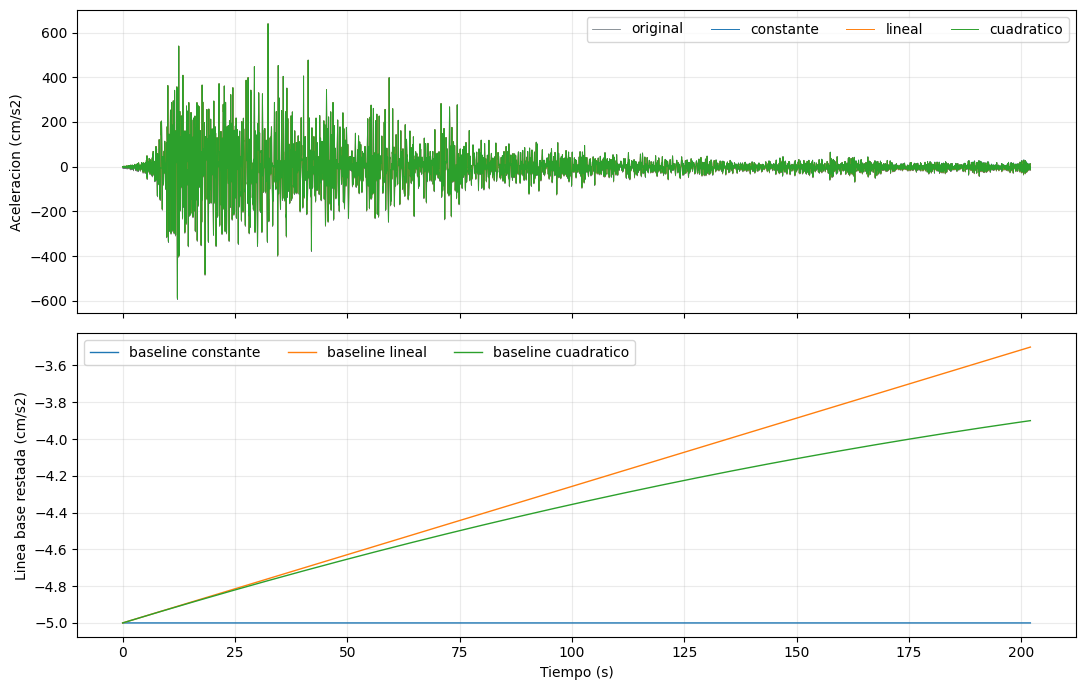

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(raw.time, raw.as_units('cm/s^2').acceleration, color='#6c757d', lw=0.55, label='original')
for name, result_case in baseline_only_results.items():
    axes[0].plot(result_case.record.time, result_case.record.as_units('cm/s^2').acceleration, lw=0.7, label=name)
axes[0].set_ylabel('Aceleracion (cm/s2)')
axes[0].grid(alpha=0.25)
axes[0].legend(ncol=4)

for name, coeffs in USER_BASELINE_CASES.items():
    curve = baseline_curve_from_coefficients(coeffs, raw.npts)
    axes[1].plot(raw.time, 100.0 * curve, lw=1.0, label=f'baseline {name}')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Linea base restada (cm/s2)')
axes[1].grid(alpha=0.25)
axes[1].legend(ncol=3)
fig.tight_layout()

## 2. Filtrado de ruido con parametros escritos por el usuario

Este bloque concentra todos los parametros editables: baseline explicito, despiking, taper, familia de filtro, frecuencias de corte, orden, fase y correccion posterior al filtrado. Es el caso manual completo antes de consultar el recomendador.

In [6]:
# Parametros manuales definidos por el usuario.
USER_REMOVE_MEAN = False
USER_PRE_EVENT_SECONDS = None
USER_BASELINE_COEFFICIENTS = USER_BASELINE_CASES['lineal']
USER_BASELINE_ORDER = -1
USER_BASELINE_FIT_METHOD = 'global'
USER_BASELINE_FIT_POST_EVENT_START_SECONDS = None
USER_CONSTRAIN_FINAL_VELOCITY = False
USER_CONSTRAIN_FINAL_DISPLACEMENT = False

USER_DESPIKE = True
USER_SPIKE_SIGMA = 8.0
USER_TAPER_FRACTION = 0.01

USER_FILTER_TYPE = 'butterworth'       # butterworth, cheby1, cheby2, ellip, bessel
USER_HIGHPASS_HZ = 0.05
USER_LOWPASS_HZ = 25.0
USER_FILTER_ORDER = 4
USER_FILTER_RIPPLE_DB = 0.5            # usado por cheby1 y ellip
USER_FILTER_ATTENUATION_DB = 40.0      # usado por cheby2 y ellip
USER_BESSEL_NORM = 'phase'             # phase, delay, mag
USER_ZERO_PHASE = True                 # True = filtfilt acausal de fase cero

USER_POST_FILTER_BASELINE_ORDER = 1
USER_POST_FILTER_BASELINE_FIT_METHOD = 'quiet_windows'
USER_POST_FILTER_BASELINE_FIT_POST_EVENT_START_SECONDS = 90.0
USER_POST_FILTER_BASELINE_COEFFICIENTS = None
USER_POST_FILTER_CONSTRAIN_FINAL_VELOCITY = True
USER_POST_FILTER_CONSTRAIN_FINAL_DISPLACEMENT = True

manual_filter_config = CorrectionConfig(
    remove_mean=USER_REMOVE_MEAN,
    pre_event_seconds=USER_PRE_EVENT_SECONDS,
    baseline_order=USER_BASELINE_ORDER,
    baseline_fit_method=USER_BASELINE_FIT_METHOD,
    baseline_fit_post_event_start_seconds=USER_BASELINE_FIT_POST_EVENT_START_SECONDS,
    baseline_coefficients=USER_BASELINE_COEFFICIENTS,
    constrain_final_velocity=USER_CONSTRAIN_FINAL_VELOCITY,
    constrain_final_displacement=USER_CONSTRAIN_FINAL_DISPLACEMENT,
    despike=USER_DESPIKE,
    spike_sigma=USER_SPIKE_SIGMA,
    taper_fraction=USER_TAPER_FRACTION,
    highpass_hz=USER_HIGHPASS_HZ,
    lowpass_hz=USER_LOWPASS_HZ,
    filter_order=USER_FILTER_ORDER,
    filter_type=USER_FILTER_TYPE,
    filter_ripple_db=USER_FILTER_RIPPLE_DB,
    filter_attenuation_db=USER_FILTER_ATTENUATION_DB,
    bessel_norm=USER_BESSEL_NORM,
    zero_phase=USER_ZERO_PHASE,
    post_filter_baseline_order=USER_POST_FILTER_BASELINE_ORDER,
    post_filter_baseline_fit_method=USER_POST_FILTER_BASELINE_FIT_METHOD,
    post_filter_baseline_fit_post_event_start_seconds=USER_POST_FILTER_BASELINE_FIT_POST_EVENT_START_SECONDS,
    post_filter_baseline_coefficients=USER_POST_FILTER_BASELINE_COEFFICIENTS,
    post_filter_constrain_final_velocity=USER_POST_FILTER_CONSTRAIN_FINAL_VELOCITY,
    post_filter_constrain_final_displacement=USER_POST_FILTER_CONSTRAIN_FINAL_DISPLACEMENT,
)

manual_result = correct_record(raw, manual_filter_config)
manual_acc = manual_result.record.as_units('cm/s^2')
manual_label = 'Usuario manual: baseline lineal + filtro Butterworth 0.05-25 Hz'

pd.DataFrame([asdict(manual_filter_config)]).T.rename(columns={0: 'valor_usuario'})

,valor_usuario
remove_mean,False
pre_event_seconds,None
baseline_order,-1
baseline_fit_method,global
baseline_fit_post_event_start_seconds,None
constrain_final_velocity,False
constrain_final_displacement,False
target_final_velocity,0.0
target_final_displacement,0.0
baseline_coefficients,"(-0.05, 0.015)"


In [7]:
manual_diagnostics_table = pd.DataFrame([
    {
        'etapa': 'pre-filtro',
        'fuente': manual_result.diagnostics.get('pre_filter_baseline_source', ''),
        'metodo_ajuste': manual_result.diagnostics.get('pre_filter_baseline_fit_method', ''),
        'orden': manual_result.diagnostics.get('pre_filter_baseline_order', ''),
        'coeficientes_m_s2': coefficients_to_text(manual_result.diagnostics.get('pre_filter_baseline_coefficients')),
        'coeficientes_cm_s2': coefficients_to_text_cm_s2(manual_result.diagnostics.get('pre_filter_baseline_coefficients')),
    },
    {
        'etapa': 'post-filtro',
        'fuente': manual_result.diagnostics.get('post_filter_baseline_source', ''),
        'metodo_ajuste': manual_result.diagnostics.get('post_filter_baseline_fit_method', ''),
        'orden': manual_result.diagnostics.get('post_filter_baseline_order', ''),
        'coeficientes_m_s2': coefficients_to_text(manual_result.diagnostics.get('post_filter_baseline_coefficients')),
        'coeficientes_cm_s2': coefficients_to_text_cm_s2(manual_result.diagnostics.get('post_filter_baseline_coefficients')),
    },
]).set_index('etapa')

manual_diagnostics_table

,fuente,metodo_ajuste,orden,coeficientes_m_s2,coeficientes_cm_s2
etapa,,,,,
pre-filtro,user_coefficients,explicit_coefficients,1,"-0.05, 0.015","-5, 1.5"
post-filtro,estimated,quiet_windows,1,"-0.0001224394755, 0.0001807262439","-0.01224394755, 0.01807262439"


## 3. Recomendacion automatica trazable

Despues de los casos manuales, se ejecuta el recomendador. La salida incluye ventanas estimadas, parametros sugeridos, ranking y desglose del score por componente. Un score menor es mejor.

In [8]:
FILTER_TYPES_RECOMMENDATION = 'butterworth'
# Otras opciones: 'all', 'bessel', 'cheby1', 'cheby2', 'ellip' o listas como ['butterworth', 'bessel'].

recommendation = recommend_correction_method(
    raw,
    t_min=0.05,
    t_max=3.0,
    snr_threshold=3.0,
    filter_types=FILTER_TYPES_RECOMMENDATION,
)
params = recommendation.parameter_suggestion
recommended = recommendation.best
result = recommended.result
project_acc = result.record.as_units('cm/s^2')
project_label = f'Proyecto recomendado ({recommended.name})'

print('\n'.join(recommendation.decision_notes))
print('Notas de parametros:')
for note in params.notes:
    print(f'- {note}')

pd.DataFrame([params.to_row()]).T.rename(columns={0: 'valor_sugerido'})

Metodo recomendado: baseline_0_hp_0.1_postpoly_1_vf_df.
Familias de filtro consideradas: butterworth.
Los parametros se estimaron con ventanas Arias, ajuste de baseline ponderado por ventanas quietas, SNR Fourier, drift terminal y sensibilidad de baseline/filtro.
Principales contribuciones al score ganador: rango post-evento de desplazamiento=0.274, penalizacion por complejidad=0.25, penalizacion por filtro=0.19.
Coeficientes recomendados de baseline pre-filtro [m/s^2, tau 0-1]: 0.009941875409.
Coeficientes recomendados de baseline post-filtro [m/s^2, tau 0-1]: 1.086244152e-05, -1.667968409e-05.
La seleccion penaliza desplazamiento/velocidad de largo periodo no fisicos, deriva y tendencia post-evento sin distorsionar excesivamente PGA, Arias, CAV ni espectro.
Si el registro puede contener desplazamiento permanente fisico, revise manualmente candidatos con desplazamiento final impuesto.
Notas de parametros:
- Ventana pre-evento estimada: 10.873645819988228 s.
- Deriva cruda: velocidad f

,valor_sugerido
pre_event_seconds,10.873646
baseline_orders,"1, 2, 0"
highpass_hz_candidates,"None, 0.02, 0.0244, 0.0391, 0.05, 0.08, 0.1"
lowpass_hz,25.0
taper_fraction,0.01
filter_order,4
filter_types,butterworth
despike,True
spike_sigma,8.0
constrain_final_velocity,True


In [9]:
recommended_baseline_table = pd.DataFrame([
    {
        'etapa': 'pre-filtro',
        'fuente': result.diagnostics.get('pre_filter_baseline_source', ''),
        'metodo_ajuste': result.diagnostics.get('pre_filter_baseline_fit_method', ''),
        'orden': result.diagnostics.get('pre_filter_baseline_order', recommended.config.baseline_order),
        'coeficientes_m_s2': coefficients_to_text(result.diagnostics.get('pre_filter_baseline_coefficients')),
        'coeficientes_cm_s2': coefficients_to_text_cm_s2(result.diagnostics.get('pre_filter_baseline_coefficients')),
        'muestras_quietas': (result.diagnostics.get('pre_filter_baseline_weighting', {}) or {}).get('quiet_sample_count', ''),
    },
    {
        'etapa': 'post-filtro',
        'fuente': result.diagnostics.get('post_filter_baseline_source', ''),
        'metodo_ajuste': result.diagnostics.get('post_filter_baseline_fit_method', ''),
        'orden': result.diagnostics.get('post_filter_baseline_order', recommended.config.post_filter_baseline_order),
        'coeficientes_m_s2': coefficients_to_text(result.diagnostics.get('post_filter_baseline_coefficients')),
        'coeficientes_cm_s2': coefficients_to_text_cm_s2(result.diagnostics.get('post_filter_baseline_coefficients')),
        'muestras_quietas': (result.diagnostics.get('post_filter_baseline_weighting', {}) or {}).get('quiet_sample_count', ''),
    },
]).set_index('etapa')

recommended_baseline_table

,fuente,metodo_ajuste,orden,coeficientes_m_s2,coeficientes_cm_s2,muestras_quietas
etapa,,,,,,
pre-filtro,estimated,quiet_windows,0,0.009941875409,0.9941875409,12002
post-filtro,estimated,quiet_windows,1,"1.086244152e-05, -1.667968409e-05","0.001086244152, -0.001667968409",12002


In [10]:
ranking = pd.DataFrame(recommendation.to_rows())
ranking_view = ranking[[
    'method',
    'score',
    'score_top_drivers',
    'baseline_order',
    'baseline_fit_method',
    'baseline_weighting_effective_method',
    'filter_type',
    'highpass_hz',
    'lowpass_hz',
    'final_velocity_ratio',
    'final_displacement_ratio',
    'final_displacement_pgv_seconds',
    'pgd_pgv_seconds',
    'post_event_velocity_drift_ratio',
    'post_event_displacement_range_ratio',
    'spectral_rms_log_change',
    'baseline_coefficients_mps2',
    'post_filter_baseline_coefficients_mps2',
]].head(12)

ranking_view

,method,score,score_top_drivers,baseline_order,baseline_fit_method,baseline_weighting_effective_method,filter_type,highpass_hz,lowpass_hz,final_velocity_ratio,final_displacement_ratio,final_displacement_pgv_seconds,pgd_pgv_seconds,post_event_velocity_drift_ratio,post_event_displacement_range_ratio,spectral_rms_log_change,baseline_coefficients_mps2,post_filter_baseline_coefficients_mps2
0,baseline_0_hp_0.1_postpoly_1_vf_df,0.755936,rango post-evento de desplazamiento=0.274; pen...,0,quiet_windows,quiet_windows,butterworth,0.1000,25.0,3.666165e-15,1.182503e-12,3.364928e-13,0.284560,0.000097,0.456629,0.053063,0.009941875409,"1.086244152e-05, -1.667968409e-05"
1,baseline_0_hp_0.0244_postpoly_1_vf_df,0.792609,rango post-evento de desplazamiento=0.33; pena...,0,quiet_windows,quiet_windows,butterworth,0.0244,25.0,4.129023e-14,2.495472e-12,2.927696e-12,1.173203,0.012755,0.550432,0.053622,0.009941875409,"-0.0001687522729, 0.0002548966905"
2,baseline_0_hp_0.1,0.815187,rango post-evento de desplazamiento=0.474; pen...,0,quiet_windows,quiet_windows,butterworth,0.1000,25.0,1.372206e-03,9.804960e-01,2.913099e-01,0.297105,0.000549,0.790318,0.053063,0.009941875409,
3,baseline_0_hp_0.02_postpoly_1_vf_df,0.815369,rango post-evento de desplazamiento=0.342; pen...,0,quiet_windows,quiet_windows,butterworth,0.0200,25.0,4.805351e-14,2.373916e-12,3.355376e-12,1.413435,0.008878,0.569746,0.053608,0.009941875409,"-0.0002078128164, 0.000311424375"
4,baseline_1_hp_0.1_postpoly_1_vf_df,0.829442,penalizacion por complejidad=0.3; rango post-e...,1,quiet_windows,quiet_windows,butterworth,0.1000,25.0,4.362196e-15,1.352744e-12,4.064518e-13,0.300465,0.001083,0.491208,0.053059,"0.01738931522, -0.01489487962","-1.269630506e-05, 1.957075535e-05"
5,baseline_1_hp_0.1,0.830895,rango post-evento de desplazamiento=0.431; pen...,1,quiet_windows,quiet_windows,butterworth,0.1000,25.0,1.578483e-03,9.814874e-01,3.380531e-01,0.344429,0.000549,0.718041,0.053058,"0.01738931522, -0.01489487962",
6,baseline_2_hp_0.1_postpoly_1_vf_df,0.846529,penalizacion por complejidad=0.35; rango post-...,2,quiet_windows,quiet_windows,butterworth,0.1000,25.0,7.087205e-16,6.765270e-13,2.003746e-13,0.296181,0.000213,0.438850,0.053063,"0.008905489831, 0.03330285588, -0.04684512702","1.324429332e-05, -1.818397802e-05"
7,baseline_2_hp_0.1,0.895800,rango post-evento de desplazamiento=0.433; pen...,2,quiet_windows,quiet_windows,butterworth,0.1000,25.0,2.259867e-03,9.949958e-01,3.948186e-01,0.396804,0.000553,0.721709,0.053064,"0.008905489831, 0.03330285588, -0.04684512702",
8,baseline_0_hp_0.05_postpoly_1_vf_df,0.924242,rango post-evento de desplazamiento=0.457; pen...,0,quiet_windows,quiet_windows,butterworth,0.0500,25.0,3.331177e-14,3.103437e-12,2.360891e-12,0.760734,0.015964,0.760905,0.053501,0.009941875409,"-0.0001388499552, 0.0002071589921"
9,baseline_2_hp_0.0244_postpoly_1_vf_df,0.950459,rango post-evento de desplazamiento=0.391; pen...,2,quiet_windows,quiet_windows,butterworth,0.0244,25.0,3.187164e-14,2.282527e-12,2.390431e-12,1.047274,0.020380,0.651114,0.053619,"0.008905489831, 0.03330285588, -0.04684512702","-0.0001336526062, 0.0002026178792"


In [11]:
trace_best = pd.DataFrame(recommended.trace_rows())
trace_best[[
    'component',
    'raw_value',
    'threshold',
    'weight',
    'normalized_value',
    'contribution',
    'description',
]].sort_values('contribution', ascending=False)

,component,raw_value,threshold,weight,normalized_value,contribution,description
5,rango post-evento de desplazamiento,4.566293e-01,0.200000,0.12,2.283146e+00,2.739776e-01,Rango post-evento normalizado por PGD.
10,penalizacion por complejidad,2.500000e-01,NaN,1.00,2.500000e-01,2.500000e-01,"Penaliza polinomios, restricciones y etapas ex..."
11,penalizacion por filtro,1.900000e-01,NaN,1.00,1.900000e-01,1.900000e-01,"Penaliza cortes high-pass agresivos, fase caus..."
3,PGD/PGV,2.845598e-01,2.500000,0.24,1.138239e-01,2.731774e-02,Escala temporal PGD/PGV; identifica desplazami...
6,cambio espectral,5.306292e-02,0.300105,0.06,1.768147e-01,1.060888e-02,RMS logaritmico entre espectro corregido y crudo.
7,cambio Arias,2.516723e-02,0.405465,0.03,6.207002e-02,1.862101e-03,Cambio logaritmico de intensidad de Arias.
8,cambio PGA,1.699293e-02,0.223144,0.02,7.615244e-02,1.523049e-03,Cambio logaritmico de PGA.
9,cambio CAV,2.128038e-02,0.405465,0.01,5.248388e-02,5.248388e-04,Cambio logaritmico de CAV.
4,tendencia post-evento de velocidad,9.721212e-05,0.080000,0.10,1.215151e-03,1.215151e-04,Pendiente post-evento normalizada por PGV.
1,desplazamiento final,1.182503e-12,0.800000,0.04,1.478129e-12,5.912515e-14,|u(T)| normalizado por PGD; detecta offset res...


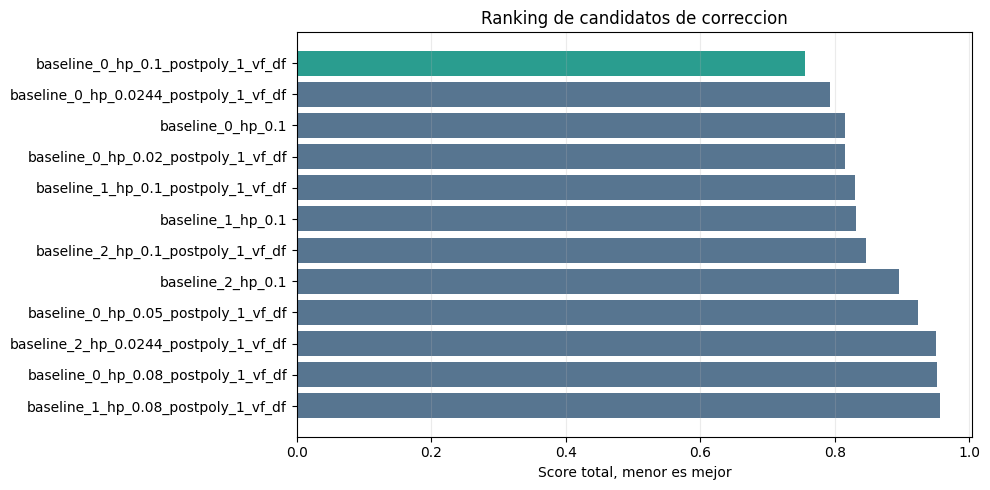

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
top = ranking.head(12).iloc[::-1]
colors = ['#2a9d8f' if method == recommended.name else '#577590' for method in top['method']]
ax.barh(top['method'], top['score'], color=colors)
ax.set_xlabel('Score total, menor es mejor')
ax.set_title('Ranking de candidatos de correccion')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()

## 4. Comparacion manual vs recomendacion vs USGS

La comparacion incluye el resultado manual completo, el candidato recomendado y los productos USGS publicados. Para USGS, las metricas de velocidad y desplazamiento usan sus canales publicados.

In [13]:
raw_vel_mps, raw_disp_m = integrate_motion(raw.acceleration_si(), raw.dt)
project_vel_cms = result.velocity * 100.0
project_disp_cm = result.displacement * 100.0
manual_vel_cms = manual_result.velocity * 100.0
manual_disp_cm = manual_result.displacement * 100.0
raw_vel_cms = raw_vel_mps * 100.0
raw_disp_cm = raw_disp_m * 100.0

n_ref = min(reference_acc.npts, reference_vel.npts, reference_disp.npts)
usgs_metrics = compute_ground_motion_parameters_from_series(
    reference_acc.time[:n_ref],
    reference_acc.acceleration_si()[:n_ref],
    velocity_si=reference_vel.acceleration[:n_ref] * 0.01,
    displacement_si=reference_disp.acceleration[:n_ref] * 0.01,
)

summary = pd.DataFrame([
    metrics_row('original', compute_ground_motion_parameters(raw)),
    metrics_row(manual_label, manual_result.metrics),
    metrics_row(project_label, result.metrics),
    metrics_row('USGS canales publicados', usgs_metrics),
]).set_index('stage')

summary[[
    'pga_cm_s2',
    'pgv_cm_s',
    'pgd_cm',
    'arias_intensity_m_s',
    'd5_95_s',
    'final_velocity_cm_s',
    'final_displacement_cm',
]]

,pga_cm_s2,pgv_cm_s,pgd_cm,arias_intensity_m_s,d5_95_s,final_velocity_cm_s,final_displacement_cm
stage,,,,,,,
original,634.160000,983.887637,93243.256062,17.408084,71.880641,-9.836970e+02,-9.324326e+04
Usuario manual: baseline lineal + filtro Butterworth 0.05-25 Hz,645.876205,37.588061,26.993067,16.977961,70.601338,1.147236e-12,7.249188e-11
Proyecto recomendado (baseline_0_hp_0.1_postpoly_1_vf_df),645.028315,37.161846,10.574766,16.975438,70.599808,-1.362414e-13,-1.250469e-11
USGS canales publicados,638.320000,38.087000,20.069000,17.329166,69.697811,-2.879100e-02,-5.730300e-01


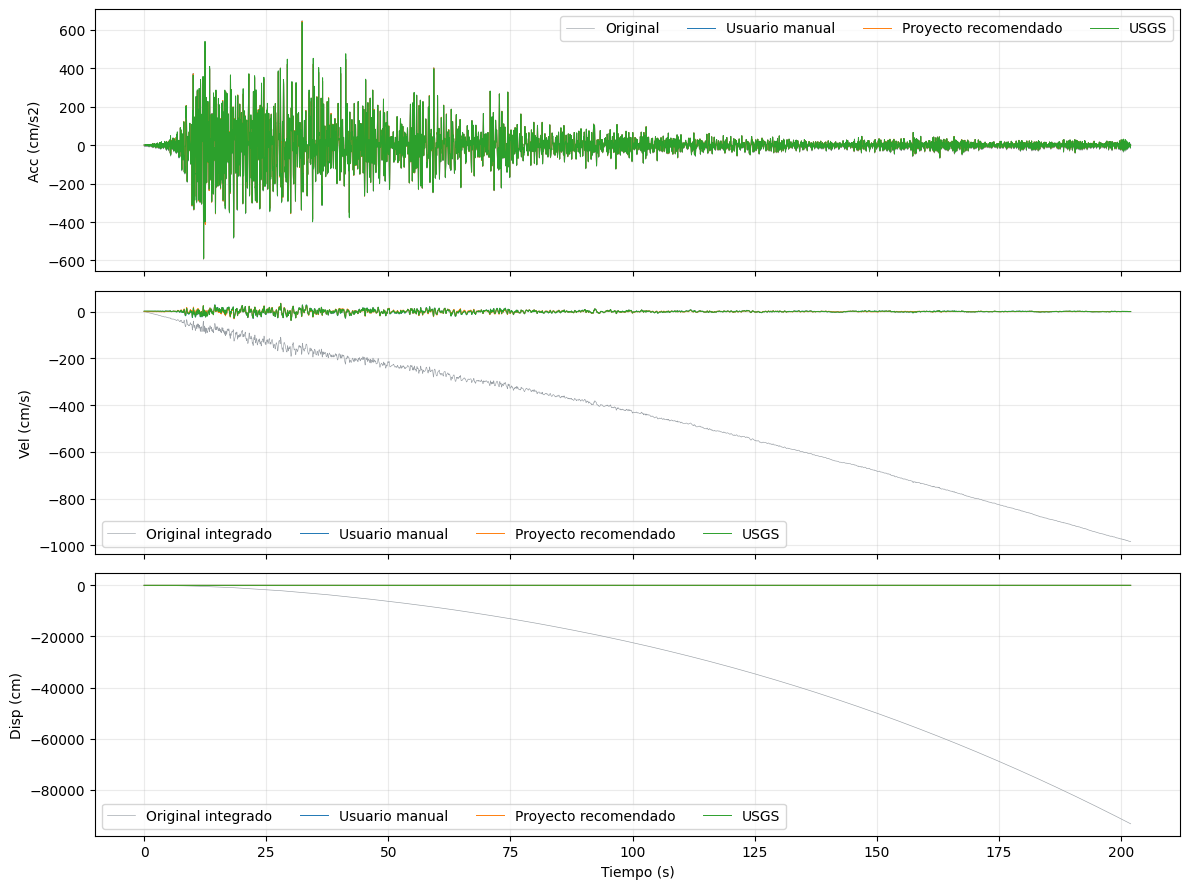

In [14]:
n_acc = min(raw.npts, project_acc.npts, manual_acc.npts, reference_acc.npts)
n_vel = min(raw.npts, result.velocity.size, manual_result.velocity.size, reference_vel.npts)
n_disp = min(raw.npts, result.displacement.size, manual_result.displacement.size, reference_disp.npts)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(raw.time[:n_acc], raw.as_units('cm/s^2').acceleration[:n_acc], color='#9aa0a6', lw=0.45, label='Original')
axes[0].plot(manual_acc.time[:n_acc], manual_acc.acceleration[:n_acc], lw=0.7, label='Usuario manual')
axes[0].plot(project_acc.time[:n_acc], project_acc.acceleration[:n_acc], lw=0.7, label='Proyecto recomendado')
axes[0].plot(reference_acc.time[:n_acc], reference_acc.acceleration[:n_acc], lw=0.7, label='USGS')
axes[0].set_ylabel('Acc (cm/s2)')

axes[1].plot(raw.time[:n_vel], raw_vel_cms[:n_vel], color='#9aa0a6', lw=0.45, label='Original integrado')
axes[1].plot(raw.time[:n_vel], manual_vel_cms[:n_vel], lw=0.7, label='Usuario manual')
axes[1].plot(raw.time[:n_vel], project_vel_cms[:n_vel], lw=0.7, label='Proyecto recomendado')
axes[1].plot(reference_vel.time[:n_vel], reference_vel.acceleration[:n_vel], lw=0.7, label='USGS')
axes[1].set_ylabel('Vel (cm/s)')

axes[2].plot(raw.time[:n_disp], raw_disp_cm[:n_disp], color='#9aa0a6', lw=0.45, label='Original integrado')
axes[2].plot(raw.time[:n_disp], manual_disp_cm[:n_disp], lw=0.7, label='Usuario manual')
axes[2].plot(raw.time[:n_disp], project_disp_cm[:n_disp], lw=0.7, label='Proyecto recomendado')
axes[2].plot(reference_disp.time[:n_disp], reference_disp.acceleration[:n_disp], lw=0.7, label='USGS')
axes[2].set_ylabel('Disp (cm)')
axes[2].set_xlabel('Tiempo (s)')

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(ncol=4)
fig.tight_layout()

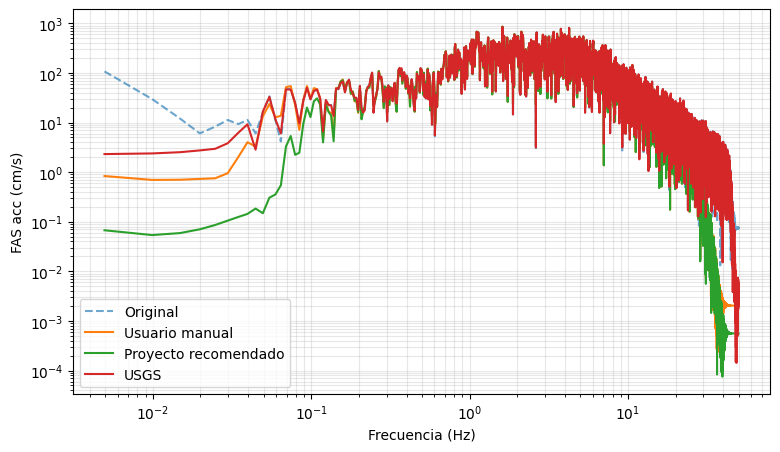

In [15]:
def fas_acc_cm_s(record):
    freqs, amp_m_s = fourier_amplitude_spectrum(record)
    return freqs, amp_m_s * 100.0

freq_raw, fas_raw = fas_acc_cm_s(raw)
freq_manual, fas_manual = fas_acc_cm_s(manual_result.record)
freq_project, fas_project = fas_acc_cm_s(result.record)
freq_usgs, fas_usgs = fas_acc_cm_s(reference_acc)

plt.figure(figsize=(9, 5))
plt.loglog(freq_raw[1:], fas_raw[1:], '--', alpha=0.65, label='Original')
plt.loglog(freq_manual[1:], fas_manual[1:], label='Usuario manual')
plt.loglog(freq_project[1:], fas_project[1:], label='Proyecto recomendado')
plt.loglog(freq_usgs[1:], fas_usgs[1:], label='USGS')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('FAS acc (cm/s)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

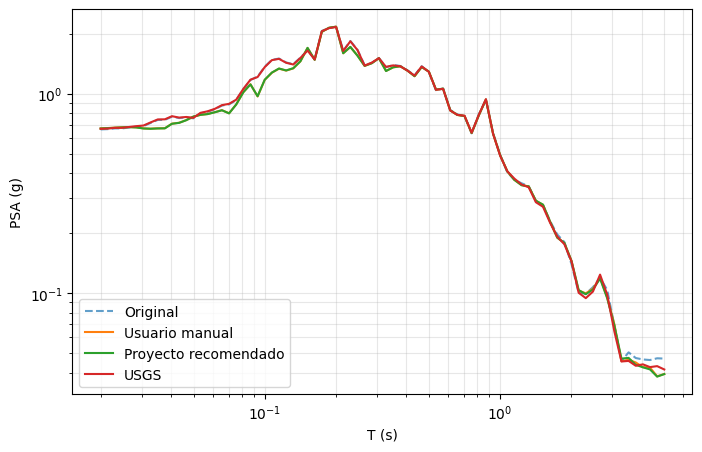

In [16]:
periods = np.geomspace(0.02, 5.0, 80)
spec_raw = response_spectrum(raw, periods)
spec_manual = response_spectrum(manual_acc, periods)
spec_project = response_spectrum(project_acc, periods)
spec_usgs = response_spectrum(reference_acc, periods)

plt.figure(figsize=(8, 5))
plt.loglog(spec_raw.periods, spec_raw.sa, '--', alpha=0.7, label='Original')
plt.loglog(spec_manual.periods, spec_manual.sa, label='Usuario manual')
plt.loglog(spec_project.periods, spec_project.sa, label='Proyecto recomendado')
plt.loglog(spec_usgs.periods, spec_usgs.sa, label='USGS')
plt.xlabel('T (s)')
plt.ylabel('PSA (g)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()